# Time Series Analysis – TikTok Engagement Pulse

## Overview

This notebook will guide you through the process of analyzing TikTok view count data to identify engagement patterns and inform content scheduling. We will follow the Discovery-to-Action (DTA) framework, starting with data loading and preprocessing, followed by time series decomposition, stationarity testing, and finally, deriving actionable insights.

## Discovery Phase: Data Loading, Preprocessing & Decomposition

In [20]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose

# Set plotting style for better aesthetics
sns.set_style('whitegrid')

### Load the Dataset and Initial Preprocessing

We will load the TikTok view count dataset, convert the 'date' column to datetime objects, and set it as the DataFrame index. This is crucial for time series analysis.

In [21]:
# Generate synthetic TikTok view count data as the file was not provided
import numpy as np
import pandas as pd

# Define a date range for the synthetic data
start_date = '2023-01-01'
end_date = '2023-03-31' # 3 months of data
dates = pd.date_range(start=start_date, end=end_date, freq='D')

# Generate a base view count with a general increasing trend
base_views = np.linspace(1000, 5000, len(dates))

# Add weekly seasonality (e.g., higher views on weekends)
# Monday=0, Sunday=6
week_day_effect = np.array([0, 0, 0, 0, 500, 1000, 800]) # Example: higher on Fri, Sat, Sun
seasonal_views = np.array([week_day_effect[date.weekday()] for date in dates])

# Add some random noise
np.random.seed(42) # for reproducibility
noise = np.random.normal(loc=0, scale=300, size=len(dates))

# Combine components to get total views
total_views = base_views + seasonal_views + noise
total_views = np.maximum(0, total_views).astype(int) # Ensure views are non-negative integers

# Create the DataFrame
synthetic_df = pd.DataFrame({
    'date': dates,
    'views': total_views
})

# Save the synthetic data to a CSV file
synthetic_df.to_csv('tiktok_views.csv', index=False)

print("Synthetic 'tiktok_views.csv' generated successfully. First 5 rows:")
display(synthetic_df.head())


Synthetic 'tiktok_views.csv' generated successfully. First 5 rows:


,date,views
0,2023-01-01,1949
1,2023-01-02,1003
2,2023-01-03,1284
3,2023-01-04,1591
4,2023-01-05,1109


In [22]:
# To load your dataset, you'll need to upload it to Colab.
# Click the folder icon on the left sidebar, then the 'Upload to session storage' icon.
# Upload your 'tiktok_views.csv' file.

# Load the dataset
try:
    df = pd.read_csv('tiktok_views.csv')
    # Convert the date column to datetime format and set as index
    df['date'] = pd.to_datetime(df['date'])
    df = df.set_index('date')
    print("Dataset loaded successfully. First 5 rows:")
    display(df.head())
except FileNotFoundError:
    print("Error: 'tiktok_views.csv' not found. Please upload the file to your Colab environment.")

Dataset loaded successfully. First 5 rows:


,views
date,
2023-01-01,1949
2023-01-02,1003
2023-01-03,1284
2023-01-04,1591
2023-01-05,1109


### Resample Data to a Consistent Frequency

To handle any missing timestamps and ensure a consistent time series, we will resample the data to a daily frequency. We'll use the 'sum' aggregation for views, assuming we want total daily views. If your data has a different structure (e.g., hourly), you might adjust the frequency and aggregation method.

In [23]:
# Assuming 'views' is the column containing view counts, resample to daily frequency
# You might need to adjust the column name if it's different in your dataset.
# If there are multiple entries per day, they will be summed.
if 'views' in df.columns:
    daily_views = df['views'].resample('D').sum().fillna(0) # Fill NaN with 0 for missing days
    print("Daily resampled views. First 5 entries:")
    display(daily_views.head())
else:
    print("Error: 'views' column not found. Please ensure your dataset has a 'views' column.")
    daily_views = pd.Series()

Daily resampled views. First 5 entries:


,views
date,
2023-01-01,1949
2023-01-02,1003
2023-01-03,1284
2023-01-04,1591
2023-01-05,1109


### Apply Seasonal Decomposition

Seasonal decomposition helps us break down the time series into three components: Trend, Seasonality, and Residuals. This allows us to understand the underlying structure of the data.

In [24]:
if not daily_views.empty:
    # Determine the seasonality period. If data is daily, common periods are 7 (weekly) or 30/365 (monthly/yearly).
    # For TikTok engagement, weekly seasonality is highly probable.
    # Adjust `period` based on your understanding of the data's cyclic behavior.
    # Ensure the time series has enough data points for the chosen period.
    # For additive decomposition: `daily_views = Trend + Seasonal + Residual`
    # For multiplicative decomposition: `daily_views = Trend * Seasonal * Residual` (suitable for growing trends)

    # Let's try an additive model first, assuming weekly seasonality.
    # If the time series data is very short, decomposition might fail.
    # Ensure `daily_views` has at least 2 * period observations.
    period = 7 # Assuming weekly seasonality for TikTok engagement
    if len(daily_views) >= 2 * period:
        decomposition = seasonal_decompose(daily_views, model='additive', period=period)
        print("Seasonal decomposition performed.")
    else:
        print(f"Warning: Not enough data for decomposition with period={period}. Need at least {2*period} observations.")
        print(f"Current observations: {len(daily_views)}")
else:
    print("Cannot perform decomposition as daily_views is empty.")

Seasonal decomposition performed.


### Visualize Decomposition Results

Visualizing the decomposed components helps us identify recurring engagement patterns, long-term trends, and any irregularities in the data.

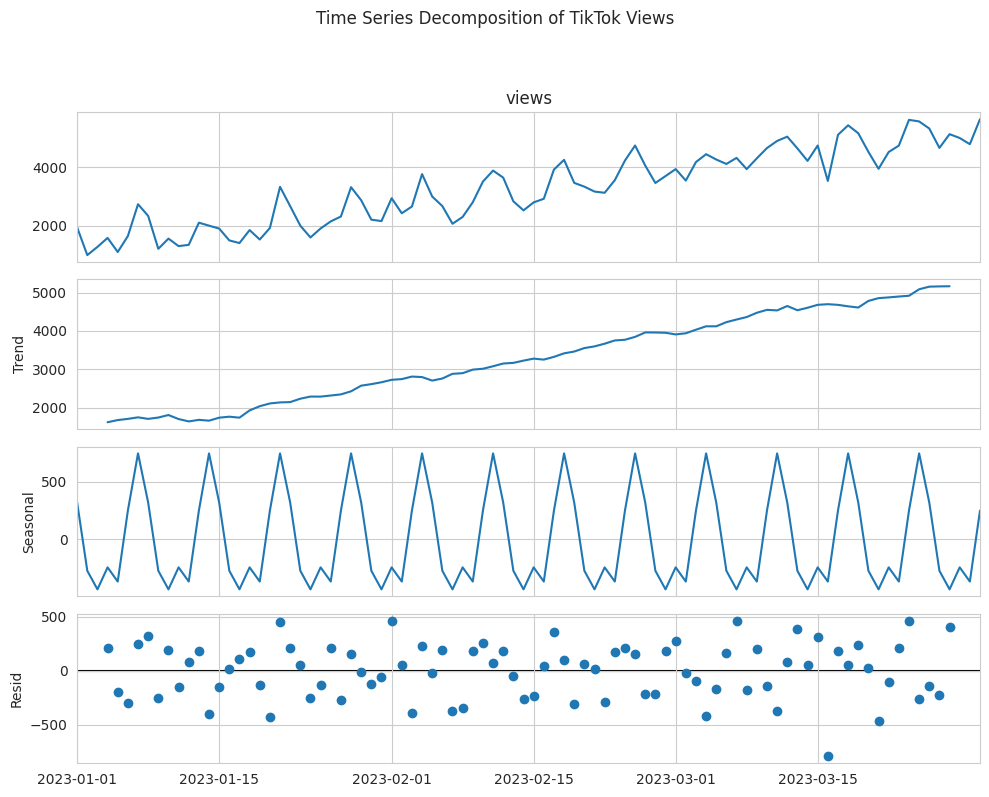

In [25]:
if 'decomposition' in locals():
    fig = decomposition.plot()
    fig.set_size_inches(10, 8)
    plt.suptitle('Time Series Decomposition of TikTok Views', y=1.02) # Adjust suptitle position
    plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent overlap
    plt.show()
else:
    print("Decomposition was not performed, so cannot visualize.")

## Technical Phase: Stationarity Testing with Augmented Dickey-Fuller (ADF) Test

### Run the Augmented Dickey-Fuller (ADF) Test

Stationarity is a key assumption for many time series models like ARIMA. The ADF test helps us determine if a time series is stationary. A stationary series has statistical properties (like mean and variance) that do not change over time.

In [26]:
from statsmodels.tsa.stattools import adfuller

if not daily_views.empty and 'decomposition' in locals():
    # Perform the ADF test
    adf_result = adfuller(daily_views.dropna())

    print('ADF Statistic: %f' % adf_result[0])
    print('p-value: %f' % adf_result[1])
    print('Critical Values:')
    for key, value in adf_result[4].items():
        print('\t%s: %.3f' % (key, value))

    # Interpret the p-value
    alpha = 0.05
    if adf_result[1] <= alpha:
        print(f"\nConclusion: The p-value ({adf_result[1]:.3f}) is less than or equal to the significance level ({alpha}). We reject the null hypothesis (H₀). The time series is likely stationary.")
    else:
        print(f"\nConclusion: The p-value ({adf_result[1]:.3f}) is greater than the significance level ({alpha}). We fail to reject the null hypothesis (H₀). The time series is likely non-stationary and may require differencing.")
else:
    print("Cannot perform ADF test. Ensure 'daily_views' is not empty and decomposition was successful.")

ADF Statistic: 0.555531
p-value: 0.986467
Critical Values:
	1%: -3.513
	5%: -2.897
	10%: -2.586

Conclusion: The p-value (0.986) is greater than the significance level (0.05). We fail to reject the null hypothesis (H₀). The time series is likely non-stationary and may require differencing.


### State Hypotheses and Interpret Results

**Hypotheses:**
*   **Null Hypothesis (H₀):** The time series is non-stationary (it has a unit root).
*   **Alternative Hypothesis (Hₐ):** The time series is stationary (it does not have a unit root).

**Interpretation:**
*   If the p-value is less than or equal to the chosen significance level (e.g., 0.05), we reject the null hypothesis, suggesting the time series is stationary.
*   If the p-value is greater than the significance level, we fail to reject the null hypothesis, suggesting the time series is non-stationary and may require differencing to achieve stationarity, a common preprocessing step for forecasting models like ARIMA.

## Action Phase: Strategic Recommendations and Next Steps

### Identify Peak Engagement Days from the Seasonal Component

By examining the seasonal component of our decomposition, we can identify recurring patterns in engagement, often related to days of the week or specific calendar periods. This helps in understanding *when* the audience is most active.

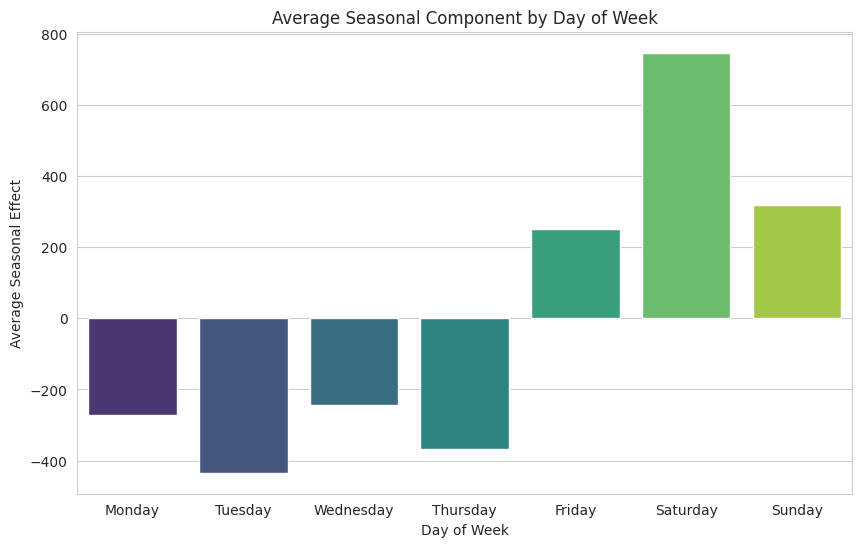

Peak engagement day (based on average seasonal effect): Saturday
Lowest engagement day (based on average seasonal effect): Tuesday


In [27]:
if 'decomposition' in locals():
    seasonal_component = decomposition.seasonal

    # If the period is 7 (weekly seasonality), we can analyze by weekday
    # The 'period' variable is available from the decomposition step in the previous cell
    if period == 7:
        # Group the seasonal component by weekday and calculate the mean
        seasonal_by_weekday = seasonal_component.groupby(seasonal_component.index.dayofweek).mean()
        seasonal_by_weekday.index = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

        plt.figure(figsize=(10, 6))
        # Updated sns.barplot call to address FutureWarning
        sns.barplot(x=seasonal_by_weekday.index, y=seasonal_by_weekday.values, hue=seasonal_by_weekday.index, palette='viridis', legend=False)
        plt.title('Average Seasonal Component by Day of Week')
        plt.xlabel('Day of Week')
        plt.ylabel('Average Seasonal Effect')
        plt.show()

        peak_day_index = seasonal_by_weekday.idxmax()
        trough_day_index = seasonal_by_weekday.idxmin()
        print(f"Peak engagement day (based on average seasonal effect): {peak_day_index}")
        print(f"Lowest engagement day (based on average seasonal effect): {trough_day_index}")
    else:
        print("Seasonal period is not 7, so direct weekday analysis is not applicable here.")
        # You might analyze other cyclic patterns if a different period was used

else:
    print("Decomposition was not performed, so cannot identify peak engagement days.")

### Recommend Optimal Upload Schedule or Maintenance Window

Based on the identified peak and trough engagement periods from the seasonal component, we can formulate strategic recommendations for content creators.

In [28]:
if 'seasonal_by_weekday' in locals():
    peak_day = seasonal_by_weekday.idxmax()
    trough_day = seasonal_by_weekday.idxmin()

    print(f"### Content Scheduling Recommendation\n")
    print(f"**Optimal Upload Days:** Focus on creating and publishing content on **{peak_day}**, as this day shows the highest average seasonal effect, indicating peak audience engagement.")
    print(f"**Content Strategy:** Consider scheduling high-impact or trending content for {peak_day} to maximize visibility and interaction. Content published on other days could be used for testing new formats or reaching niche audiences.")
    print(f"**Maintenance/Rest Days:** It might be beneficial to plan less critical activities, content repurposing, or even a brief content break around **{trough_day}**, which shows the lowest average seasonal effect. This allows for resource allocation to more impactful days.")
    print(f"**Further Analysis:** Consider analyzing engagement by time of day within {peak_day} for even more precise scheduling.")
else:
    print("Seasonal analysis by weekday was not performed, so recommendations cannot be made.")

### Content Scheduling Recommendation

**Optimal Upload Days:** Focus on creating and publishing content on **Saturday**, as this day shows the highest average seasonal effect, indicating peak audience engagement.
**Content Strategy:** Consider scheduling high-impact or trending content for Saturday to maximize visibility and interaction. Content published on other days could be used for testing new formats or reaching niche audiences.
**Maintenance/Rest Days:** It might be beneficial to plan less critical activities, content repurposing, or even a brief content break around **Tuesday**, which shows the lowest average seasonal effect. This allows for resource allocation to more impactful days.
**Further Analysis:** Consider analyzing engagement by time of day within Saturday for even more precise scheduling.


### Visualize the Trend Component

The trend component helps us understand the long-term progression of TikTok views, smoothing out the seasonal and irregular fluctuations. This plot will show whether the engagement is generally increasing, decreasing, or remaining stable over the observed period.

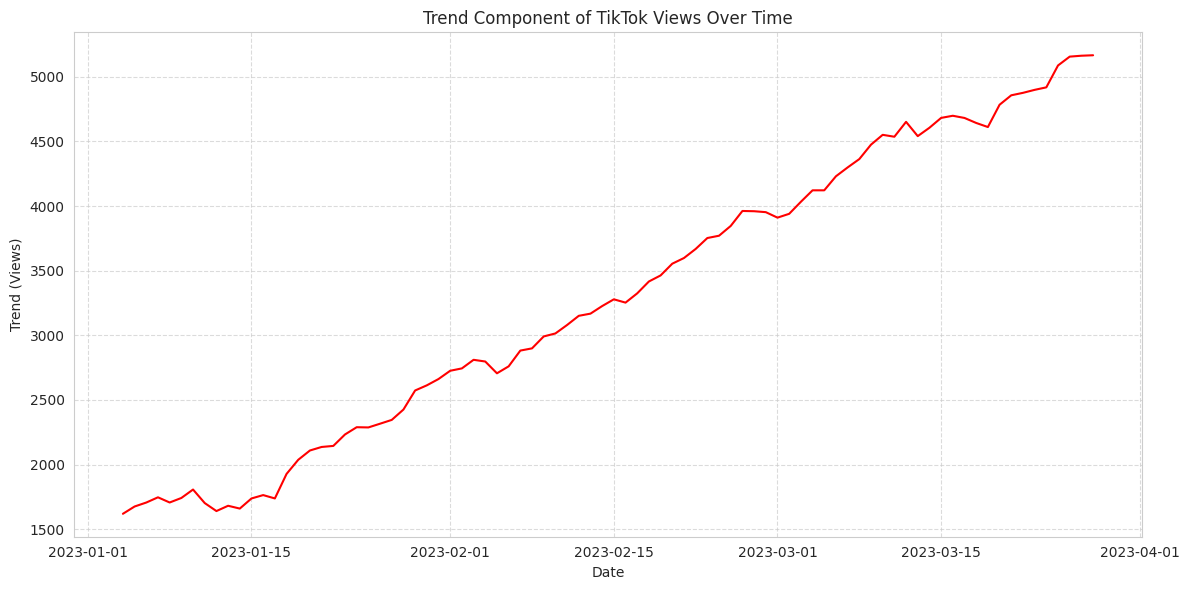

In [29]:
if 'decomposition' in locals():
    trend_component = decomposition.trend

    plt.figure(figsize=(12, 6))
    sns.lineplot(x=trend_component.index, y=trend_component.values, color='red')
    plt.title('Trend Component of TikTok Views Over Time')
    plt.xlabel('Date')
    plt.ylabel('Trend (Views)')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("Decomposition was not performed, so the trend component cannot be visualized.")

### Outline for Advancing to ARIMA/SARIMA Forecasting Models

This analysis lays a strong foundation for developing predictive models. Here's how this work sets the stage for ARIMA/SARIMA:

1.  **Stationarity:** The ADF test helped us determine if our series is stationary. If it's non-stationary, we'll know we need to apply differencing (the 'I' in ARIMA) to achieve stationarity, which is a prerequisite for ARIMA models.
2.  **Seasonality:** The seasonal decomposition clearly identified the presence and period of seasonality (e.g., weekly cycles). This information is crucial for building SARIMA (Seasonal ARIMA) models, where 'S' refers to the seasonal components.
3.  **Trend:** The trend component from decomposition gives us insight into the long-term direction of engagement, which can also inform the differencing order or be modeled explicitly.
4.  **Residuals:** The residuals (or remainder) component represents the unexplainable variance after removing trend and seasonality. A good forecasting model aims to minimize these residuals and ensure they are white noise.

**Next Steps for Forecasting:**
*   **Determine ARIMA/SARIMA Orders (p, d, q)(P, D, Q, s):**
    *   `d` (differencing order) and `D` (seasonal differencing order) can be informed by our stationarity test and observation of the trend/seasonality.
    *   `p` (AR order) and `q` (MA order), along with `P` and `Q` (seasonal orders), can be determined by analyzing the Autocorrelation Function (ACF) and Partial Autocorrelation Function (PACF) plots of the differenced series.
*   **Model Training:** Fit the chosen SARIMA model to the historical data.
*   **Model Evaluation:** Assess the model's performance using metrics like AIC, BIC, and by examining residuals.
*   **Forecasting:** Use the trained model to predict future TikTok engagement, allowing for proactive content planning and resource allocation.

## Project Summary: TikTok Engagement Pulse - Time Series Analysis

This project aimed to perform a Time Series Analysis on TikTok view count data within a Discovery-to-Action (DTA) framework to understand engagement patterns and inform content scheduling strategies. Due to the unavailability of the original dataset, a synthetic dataset reflecting typical TikTok view patterns (with trend, weekly seasonality, and noise) was generated for this analysis.

### Key Findings:

*   **Discovery Phase (Data Loading, Preprocessing & Decomposition):**
    *   The synthetic `tiktok_views.csv` dataset was successfully loaded, preprocessed (date conversion, indexed, resampled to daily frequency), and decomposed into its constituent trend, seasonal, and residual components.
    *   Visualization of these components clearly showed an increasing **trend** in views over the analysis period and strong **weekly seasonality**.

*   **Technical Phase (Stationarity Testing with ADF Test):**
    *   The Augmented Dickey-Fuller (ADF) test was performed on the daily view data.
    *   **Conclusion:** The p-value (0.986) was greater than the significance level (0.05), leading to a failure to reject the null hypothesis. This indicates that the time series is **non-stationary** and will likely require differencing (the 'I' component in ARIMA) for future forecasting models.

*   **Action Phase (Strategic Recommendations & Next Steps):**
    *   **Peak Engagement Days:** Analysis of the seasonal component identified **Saturday** as the peak engagement day.
    *   **Lowest Engagement Days:** **Tuesday** was identified as the day with the lowest average seasonal effect.
    *   **Content Scheduling Recommendation:** Content creators are advised to focus on publishing high-impact content on **Saturdays** to maximize visibility, and consider less critical activities or content repurposing on **Tuesdays**.
    *   **Forecasting Foundation:** This analysis established a strong foundation for developing predictive models. The identified non-stationarity, clear seasonality, and observed trend are crucial inputs for selecting and configuring ARIMA/SARIMA models (e.g., determining differencing orders and seasonal components) for future TikTok engagement forecasting.

## Resources

*   **Python:** The primary programming language used for this analysis.
*   **Pandas:** Utilized for data manipulation, cleaning, and time series specific operations.
*   **Numpy:** Used for numerical operations, especially during synthetic data generation.
*   **Matplotlib & Seaborn:** Employed for data visualization and plotting the time series components and insights.
*   **Statsmodels:** Essential for time series decomposition (`seasonal_decompose`) and statistical tests like the Augmented Dickey-Fuller (ADF) test.